In [2]:
import pandas as pd
import matplotlib.pyplot as plt

jf = pd.read_csv("janfeb.csv")
jj = pd.read_csv("junjul.csv")
top = jf.groupby("complaint type")["count"].sum().sort_values(ascending=False)
top.head(5)

complaint type
HEAT/HOT WATER          81641
Illegal Parking         79916
Noise - Residential     43602
Blocked Driveway        28608
UNSANITARY CONDITION    19208
Name: count, dtype: int64

In [3]:
ctype = top.index[0]   # HEAT/HOT WATER
a = jf[jf["complaint type"] == ctype].set_index("borough")["count"]
b = jj[jj["complaint type"] == ctype].set_index("borough")["count"]
cmp = pd.DataFrame({"Jan-Feb 2024": a, "Jun-Jul 2024": b}).fillna(0).astype(int)
cmp.loc["TOTAL"] = cmp.sum()
cmp

,Jan-Feb 2024,Jun-Jul 2024
borough,,
BRONX,30139,2227
BROOKLYN,20915,1929
MANHATTAN,17604,1778
QUEENS,12117,835
STATEN ISLAND,866,121
TOTAL,81641,6890


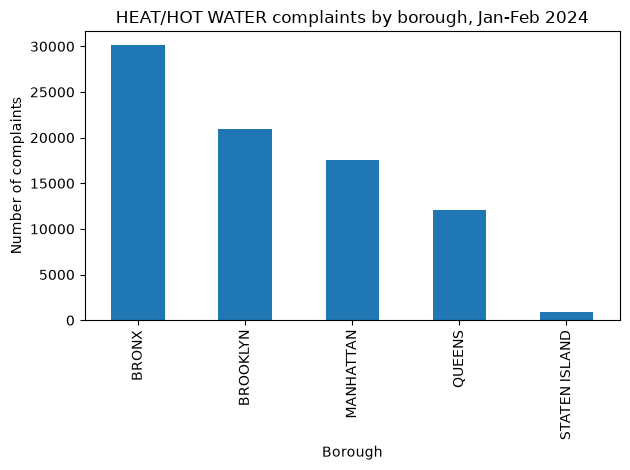

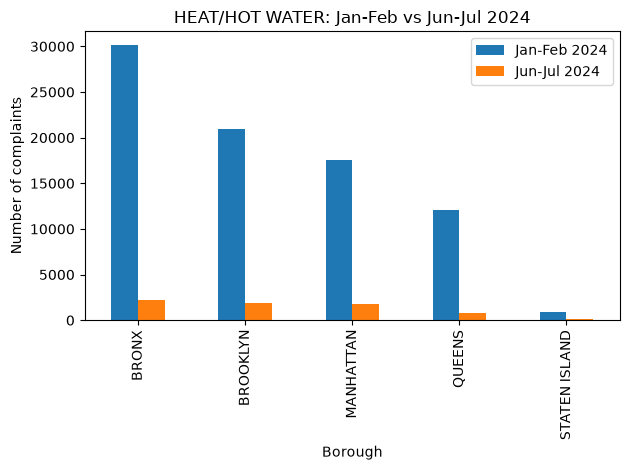

In [4]:
a.plot(kind="bar", title=f"{ctype} complaints by borough, Jan-Feb 2024")
plt.ylabel("Number of complaints"); plt.xlabel("Borough"); plt.tight_layout(); plt.show()

cmp.drop("TOTAL").plot(kind="bar", title=f"{ctype}: Jan-Feb vs Jun-Jul 2024")
plt.ylabel("Number of complaints"); plt.xlabel("Borough"); plt.tight_layout(); plt.show()